# Q3: CNN for image classification

In this assignment, you'll be coding up a convolutional neural network from scratch to classify images using PyTorch.  

### Instructions
- Install PyTorch following the instructions [here](https://pytorch.org/).
- Install the [`torchinfo` package](https://github.com/TylerYep/torchinfo) to visualize the network architecture and the number of parameters. The maximum number of parameters you are allowed to use for your network is **100,000**. Those who violate this rule will be scored 0 points!!! 
- You are required to complete the functions defined in the code blocks following each question. Fill out sections of the code marked `"YOUR CODE HERE"`.
- You're free to add any number of methods within each class.
- You may also add any number of additional code blocks that you deem necessary. 

## Data Preparation

In [1]:
# Importing the libraries
import os
import torch
import torchvision
from torchvision.utils import make_grid

import numpy as np

In this assignment, we will use the EMNIST dataset. The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19 and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset.

There are six different splits provided in this datase: byclass, bymerge, balanced, letters, digits and mnist. Here, we will choose 'balanced' split.

Further information on the dataset contents and conversion process can be found in the paper available at https://arxiv.org/abs/1702.05373v1.



### Data

Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels in total. Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255.  


EMNIST is included in the `torchvision` library.

In [2]:
from torchvision.datasets import EMNIST
from torchvision.transforms import Compose, ToTensor, Normalize

In [3]:
# Transform to normalize the data and convert to a tensor
transform = Compose([ToTensor(),
    Normalize((0.5,), (0.5,))
    ])

# Download the data
dataset = EMNIST('MNIST_data/', download = True, train = True, split = 'balanced', transform = transform)

**NOTE:** You may add more operations to `Compose` if you're performing data augmentation.

## Data Exploration

Let's take a look at the classes in our dataset.

In [4]:
print(dataset.classes)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']


In [5]:
import matplotlib.pyplot as plt

def show_example(img, label):
    print('Label: {} ({})'.format(dataset.classes[label], label))
    plt.imshow(img.squeeze(), cmap='Greys_r')
    plt.axis(False)

Label: h (42)


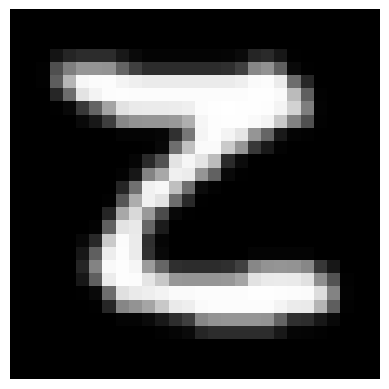

In [6]:
show_example(*dataset[20])

Label: A (10)


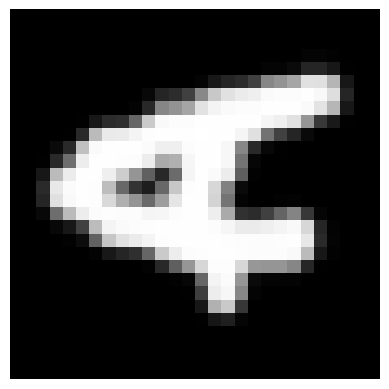

In [7]:
show_example(*dataset[20000])

## Question 1 (2 points)

## Creating Training and Validation Datasets

The `split_indices` function takes in the size of the entire dataset, `n`, the fraction of data to be used as validation set, `val_frac`, and the random seed and returns the indices of the data points to be added to the validation dataset.  

**Choose a suitable fraction for your validation set and experiment with the seed. Remember that the better your validation set, the higher the chances that your model would do well on the test set.**

In [8]:
def split_indices(n, val_frac, seed):
    # Determine the size of the validation set
    n_val = int(val_frac * n)
    np.random.seed(seed)
    # Create random permutation between 0 to n-1
    idxs = np.random.permutation(n)
    # Pick first n_val indices for validation set
    return idxs[n_val:], idxs[:n_val]

In [9]:
######################
# Scope: Q3 validation split settings only
val_frac = 0.1  # Set the fraction for the validation set
rand_seed = 42  # Set the random seed
######################

train_indices, val_indices = split_indices(len(dataset), val_frac, rand_seed)
print("#samples in training set: {}".format(len(train_indices)))
print("#samples in validation set: {}".format(len(val_indices)))

#samples in training set: 101520
#samples in validation set: 11280


Next, we make use of the built-in dataloaders in PyTorch to create iterables of our our training and validation sets. This helps in avoiding fitting the whole dataset into memory and only loads a batch of the data that we can decide. 

**Set the `batch_size` depending on the hardware resource (GPU/CPU RAM) you are using for the assignment.**

In [10]:
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data.dataloader import DataLoader

In [11]:
######################
# Scope: Q3 dataloader batch size only
batch_size = 128  # Set the batch size
######################

In [12]:
# Training sampler and data loader
train_sampler = SubsetRandomSampler(train_indices)
train_dl = DataLoader(dataset,
                     batch_size,
                     sampler=train_sampler)

# Validation sampler and data loader
val_sampler = SubsetRandomSampler(val_indices)
val_dl = DataLoader(dataset,
                   batch_size,
                   sampler=val_sampler)

Plot images in a sample batch of data.

In [13]:
def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(10,10))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images, 8).permute(1, 2, 0), cmap='Greys_r')
        break

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


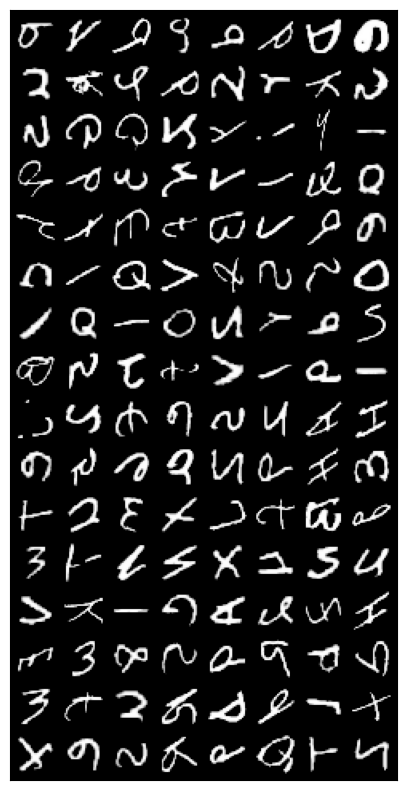

In [14]:
show_batch(train_dl)

## Question 2 (10 points)

## Building the Model

**Create your model by defining the network architecture in the `ImageClassifierNet` class.**  
**NOTE:** The number of parameters in your network must be $\leq$ 100,000.

In [15]:
# Import the libraries
import torch.nn as nn
import torch.nn.functional as F

from torchinfo import summary

In [16]:
class ImageClassifierNet(nn.Module):
    def __init__(self, n_channels=3):
        super(ImageClassifierNet, self).__init__()
        ######################
        # Scope: Q3 CNN architecture only
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.2)
        self.fc1 = nn.Linear(32 * 7 * 7, 32)
        self.fc2 = nn.Linear(32, 47)
        ######################
        
    def forward(self, X):
        ######################
        # Scope: Q3 CNN forward pass only
        X = self.pool(F.relu(self.conv1(X)))
        X = self.pool(F.relu(self.conv2(X)))
        X = X.view(X.size(0), -1)
        X = self.dropout(F.relu(self.fc1(X)))
        X = self.fc2(X)
        return X
        ######################

In [17]:
model = ImageClassifierNet()

The following code block prints your network architecture. It also shows the total number of parameters in your network (see `Total params`).  

**NOTE: The total number of parameters in your model should be <= 100,000.**

In [18]:
summary(model, input_size=(batch_size, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
ImageClassifierNet                       [128, 47]                 --
├─Conv2d: 1-1                            [128, 16, 28, 28]         160
├─MaxPool2d: 1-2                         [128, 16, 14, 14]         --
├─Conv2d: 1-3                            [128, 32, 14, 14]         4,640
├─MaxPool2d: 1-4                         [128, 32, 7, 7]           --
├─Linear: 1-5                            [128, 32]                 50,208
├─Dropout: 1-6                           [128, 32]                 --
├─Linear: 1-7                            [128, 47]                 1,551
Total params: 56,559
Trainable params: 56,559
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 139.09
Input size (MB): 0.40
Forward/backward pass size (MB): 19.35
Params size (MB): 0.23
Estimated Total Size (MB): 19.98

## Enable training on a GPU

**NOTE:** This section is necessary if you're training your model on a GPU.

In [19]:
def get_default_device():
    """Use GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
    
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)
    
    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [20]:
device = get_default_device()

train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)

to_device(model, device)

ImageClassifierNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=1568, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=47, bias=True)
)

## Question 3 (10 points)

## Train the model

**Complete the `train_model` function to train your model on a dataset. Tune your network architecture and hyperparameters on the validation set.**

In [21]:
def train_model(n_epochs, model, train_dl, val_dl, loss_fn, opt_fn, lr):
    """
    Trains the model on a dataset.
    
    Args:
        n_epochs: number of epochs
        model: ImageClassifierNet object
        train_dl: training dataloader
        val_dl: validation dataloader
        loss_fn: the loss function
        opt_fn: the optimizer
        lr: learning rate
    
    Returns:
        The trained model. 
        A tuple of (model, train_losses, val_losses, train_accuracies, val_accuracies)
    """
    # Record these values the end of each epoch
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    
    ######################
    # Scope: Q3 training and validation loop only
    optimizer = opt_fn(model.parameters(), lr=lr)
    
    for epoch in range(n_epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for images, labels in train_dl:
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
        
        train_losses.append(train_loss / train_total)
        train_accuracies.append(train_correct / train_total)
        
        if val_dl:
            model.eval()
            val_loss, val_correct, val_total = 0.0, 0, 0
            
            with torch.no_grad():
                for images, labels in val_dl:
                    outputs = model(images)
                    loss = loss_fn(outputs, labels)
                    
                    val_loss += loss.item() * images.size(0)
                    _, preds = torch.max(outputs, dim=1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)
            
            val_losses.append(val_loss / val_total)
            val_accuracies.append(val_correct / val_total)
            print("Epoch [{}/{}], train_loss: {:.4f}, val_loss: {:.4f}, train_acc: {:.4f}, val_acc: {:.4f}".format(
                epoch + 1, n_epochs, train_losses[-1], val_losses[-1], train_accuracies[-1], val_accuracies[-1]))
        else:
            print("Epoch [{}/{}], train_loss: {:.4f}, train_acc: {:.4f}".format(
                epoch + 1, n_epochs, train_losses[-1], train_accuracies[-1]))
    ######################
    
    return model, train_losses, val_losses, train_accuracies, val_accuracies

**Set the maximum number of training epochs, the loss function, the optimizer, and the learning rate.**

In [22]:
######################
# Scope: Q3 initial training hyperparameters only
num_epochs = 10  # Max number of training epochs
loss_fn = nn.CrossEntropyLoss()  # Define the loss function
opt_fn = torch.optim.Adam  # Select an optimizer
lr = 0.001  # Set the learning rate
######################

In [23]:
history = train_model(num_epochs, model, train_dl, val_dl, loss_fn, opt_fn, lr)
model, train_losses, val_losses, train_accuracies, val_accuracies = history

Epoch [1/10], train_loss: 1.7836, val_loss: 0.7818, train_acc: 0.4723, val_acc: 0.7611
Epoch [2/10], train_loss: 1.1448, val_loss: 0.6761, train_acc: 0.6351, val_acc: 0.7852
Epoch [3/10], train_loss: 1.0458, val_loss: 0.6260, train_acc: 0.6606, val_acc: 0.7961
Epoch [4/10], train_loss: 0.9957, val_loss: 0.6151, train_acc: 0.6760, val_acc: 0.8008
Epoch [5/10], train_loss: 0.9512, val_loss: 0.5753, train_acc: 0.6895, val_acc: 0.8133
Epoch [6/10], train_loss: 0.9149, val_loss: 0.5655, train_acc: 0.6999, val_acc: 0.8194
Epoch [7/10], train_loss: 0.8897, val_loss: 0.5559, train_acc: 0.7078, val_acc: 0.8168
Epoch [8/10], train_loss: 0.8660, val_loss: 0.5402, train_acc: 0.7134, val_acc: 0.8181
Epoch [9/10], train_loss: 0.8481, val_loss: 0.5277, train_acc: 0.7200, val_acc: 0.8246
Epoch [10/10], train_loss: 0.8362, val_loss: 0.5168, train_acc: 0.7225, val_acc: 0.8257


## Plot loss and accuracy

In [24]:
def plot_accuracy(train_accuracies, val_accuracies):
    """Plot accuracies"""
    plt.plot(train_accuracies, "-x")
    plt.plot(val_accuracies, "-o")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Training", "Validation"])
    plt.title("Accuracy vs. No. of epochs")

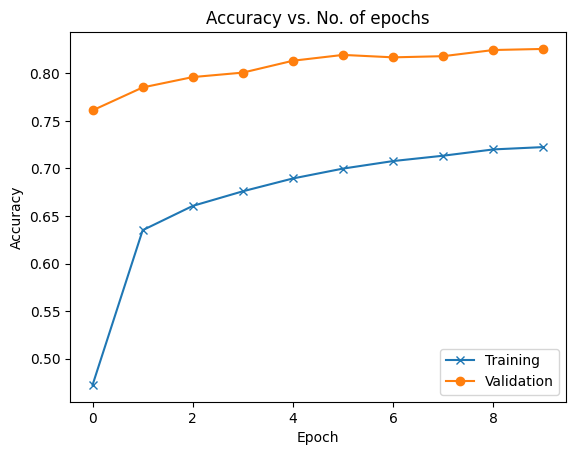

In [25]:
plot_accuracy(train_accuracies, val_accuracies)

In [26]:
def plot_losses(train_losses, val_losses):
    """Plot losses"""
    plt.plot(train_losses, "-x")
    plt.plot(val_losses, "-o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Training", "Validation"])
    plt.title("Loss vs. No. of Epochs")

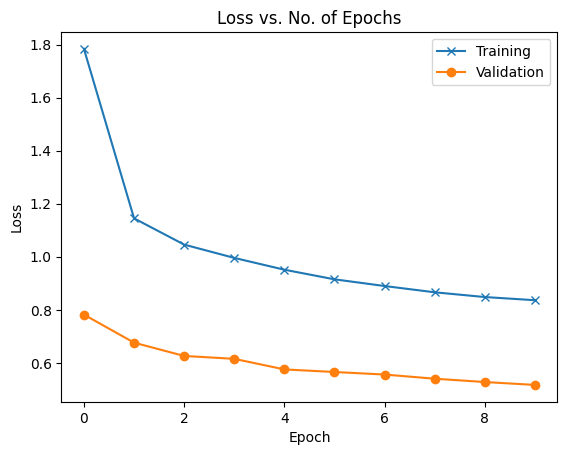

In [27]:
plot_losses(train_losses, val_losses)

## Train a model on the entire dataset

In [28]:
indices, _ = split_indices(len(dataset), 0, rand_seed)

sampler = SubsetRandomSampler(indices)
dl = DataLoader(dataset, batch_size, sampler=sampler)
dl = DeviceDataLoader(dl, device)

**Set the maximum number of training epochs and the learning rate for finetuning your model.**

In [29]:
######################
# Scope: Q3 full-dataset finetuning hyperparameters only
num_epochs = 2  # Max number of training epochs
lr = 0.0005  # Set the learning rate
######################

In [30]:
history = train_model(num_epochs, model, dl, [], loss_fn, opt_fn, lr)
model = history[0]

Epoch [1/2], train_loss: 0.8008, train_acc: 0.7347
Epoch [2/2], train_loss: 0.7904, train_acc: 0.7383


## Check Predictions

In [31]:
def view_prediction(img, label, probs, classes):
    """
    Visualize predictions.
    """
    probs = probs.cpu().numpy().squeeze()

    fig, (ax1, ax2) = plt.subplots(figsize=(8,15), ncols=2)
    ax1.imshow(img.resize_(1, 28, 28).cpu().numpy().squeeze(), cmap='Greys_r')
    ax1.axis('off')
    ax1.set_title('Actual: {}'.format(classes[label]))
    ##################
    # ax2.barh(np.arange(10), probs)
    # ax2.set_aspect(0.1)
    # ax2.set_yticks(np.arange(10))
    ax2.barh(np.arange(len(classes)), probs)
    ax2.set_aspect(0.1)
    ax2.set_yticks(np.arange(len(classes)))
    ##################

    ax2.set_yticklabels(classes, size='small');
    ax2.set_title('Predicted: probabilities')
    ax2.set_xlim(0, 1.1)

    plt.tight_layout()

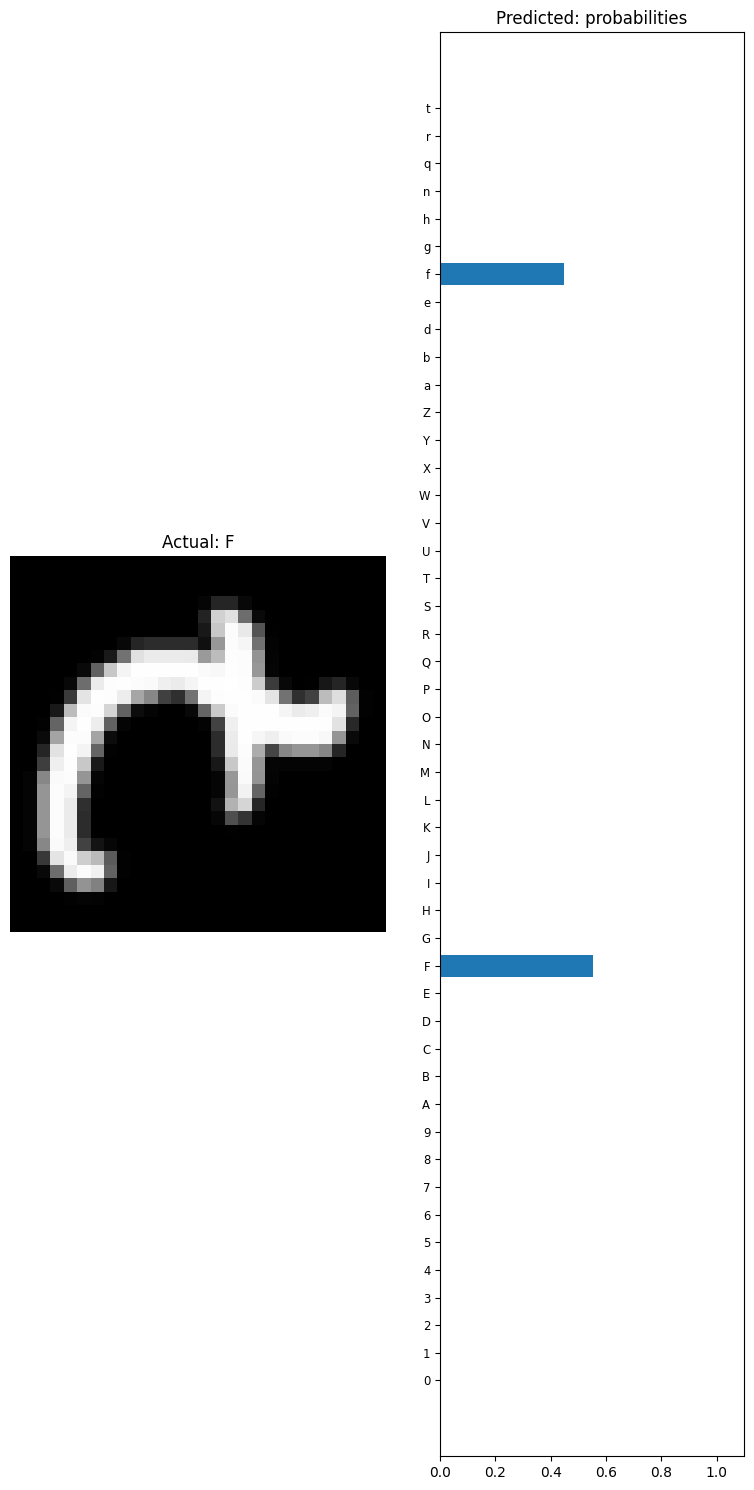

In [32]:
# Calculate the class probabilites (log softmax) for img
images = iter(dl)
for imgs, labels in images:
    with torch.no_grad():
        model.eval()
        # Calculate the class probabilites (log softmax) for img
        probs = torch.nn.functional.softmax(model(imgs[0].unsqueeze(0)), dim=1)
        # Plot the image and probabilites
        view_prediction(imgs[0], labels[0], probs, dataset.classes)
    break

## Save the model

In [33]:
# Very important
torch.save(model, 'model.pth')

## Question 4 (8 points)

## Compute accuracy on the test set

In [34]:
test_dataset = EMNIST('MNIST_data/', download = True, train = False, split = 'balanced', transform = transform)

In [35]:
test_dl = DataLoader(test_dataset, batch_size)
test_dl = DeviceDataLoader(test_dl, device)

In [36]:
def evaluate(model, test_dl):
    """
    Evaluates your model on the test data.
    
    Args:
        model: ImageClassifierNet object
        test_dl: test dataloader
    
    Returns: 
        Test accuracy.
    """
    ######################
    # Scope: Q3 test accuracy evaluation only
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for images, labels in test_dl:
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    return correct / total
    ######################

In [37]:
print("Test Accuracy = {:.4f}".format(evaluate(model, test_dl)))

Test Accuracy = 0.8307


## Tips to increase the test accuracy

- **Data augmentation:** Diversifies your training set and leads to better generalization
    - Flipping
    - Rotation
    - Shifting
    - Cropping
    - Adding noise
    - Blurring
    
- **Regularization:** Reduces overfitting on the training set
    - Early stopping
    - Dropout
    - $l_2$ regularization
    - Batch normalization

- **Hyperparameter tuning:**
    - Weight initialization
    - Learning rate
    - Activation functions
    - Optimizers

## Experiment Analysis

The assignment asks for methods and parameters tried to improve the final result. The baseline and additional experiments below were run on the HKU GPU Farm. All trainable models were kept below the 100,000-parameter limit.

| Experiment | Main change | Params | Validation accuracy | Test accuracy | Notes |
|---|---|---:|---:|---:|---|
| Baseline checkpoint | Conv16-32, dropout 0.2, Adam lr=0.001 | 56,559 | - | 0.8307 | Reference model saved as `model.pth`. |
| Baseline + AdamW + label smoothing | Same architecture, AdamW, weight decay `1e-4`, label smoothing `0.05` | 56,559 | 0.8536 | 0.8576 | Large gain over the baseline without increasing parameters. |
| TinyResNet + AdamW + label smoothing | Residual CNN with max pooling, AdamW, label smoothing `0.05` | 89,615 | 0.8629 | 0.8604 | Improved capacity while staying under the limit. |
| TinyResNet + mild augmentation + AdamW + label smoothing | Rotation/translation/scale augmentation on training data only | 89,615 | 0.7611 | 0.7829 | Underperformed; augmentation likely made the character task harder. |
| TinyResNet without block dropout | Removed dropout inside residual blocks | 89,615 | 0.8613 | 0.8622 | Small gain over the first TinyResNet. |
| TinyResNet with lower dropout | Removed block dropout and reduced FC dropout to `0.10` | 89,615 | 0.8781 | 0.8799 | Strong gain; the earlier model was over-regularized. |
| TinyResNet with label smoothing `0.02` | Reduced label smoothing from `0.05` to `0.02` | 89,615 | 0.8602 | 0.8636 | Slight test gain, but not competitive with lower dropout. |
| TinyResNet without label smoothing | Set label smoothing to `0.0` | 89,615 | 0.8630 | 0.8688 | Better than `0.05`, but still below lower dropout. |
| TinyResNet AvgPool variant | Used average pooling for the second downsampling stage | 89,615 | 0.8848 | 0.8834 | Best result; selected final checkpoint: `q3_ablation_models/tiny_resnet_avgpool_variant.pth`. |

Horizontal and vertical flips are intentionally not used because they can change EMNIST class semantics, such as `b`/`d`, `p`/`q`, `6`/`9`, and `M`/`W`. Validation and test data stay unaugmented so evaluation measures real performance, not random transformed samples.


In [38]:
######################
# Scope: Q3 additional experiment transforms only
from torchvision.transforms import RandomRotation, RandomAffine

basic_transform = Compose([
    ToTensor(),
    Normalize((0.5,), (0.5,))
])

mild_aug_transform = Compose([
    RandomRotation(10),
    RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.95, 1.05)),
    ToTensor(),
    Normalize((0.5,), (0.5,))
])
######################

In [39]:
######################
# Scope: Q3 additional experiment dataloaders only
train_aug_dataset = EMNIST('MNIST_data/', download=True, train=True, split='balanced', transform=mild_aug_transform)
val_base_dataset = EMNIST('MNIST_data/', download=True, train=True, split='balanced', transform=basic_transform)
test_base_dataset = EMNIST('MNIST_data/', download=True, train=False, split='balanced', transform=basic_transform)

train_aug_dl = DataLoader(train_aug_dataset, batch_size, sampler=SubsetRandomSampler(train_indices))
val_base_dl = DataLoader(val_base_dataset, batch_size, sampler=SubsetRandomSampler(val_indices))
test_base_dl = DataLoader(test_base_dataset, batch_size)

train_aug_dl = DeviceDataLoader(train_aug_dl, device)
val_base_dl = DeviceDataLoader(val_base_dl, device)
test_base_dl = DeviceDataLoader(test_base_dl, device)
######################

In [40]:
class BNImageClassifierNet(nn.Module):
    def __init__(self, n_channels=3):
        super(BNImageClassifierNet, self).__init__()
        ######################
        # Scope: Q3 batch-normalized CNN architecture only
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.2)
        self.fc1 = nn.Linear(32 * 7 * 7, 32)
        self.fc2 = nn.Linear(32, 47)
        ######################

    def forward(self, X):
        ######################
        # Scope: Q3 batch-normalized CNN forward pass only
        X = self.pool(F.relu(self.bn1(self.conv1(X))))
        X = self.pool(F.relu(self.bn2(self.conv2(X))))
        X = X.view(X.size(0), -1)
        X = self.dropout(F.relu(self.fc1(X)))
        X = self.fc2(X)
        return X
        ######################


class WiderBNImageClassifierNet(nn.Module):
    def __init__(self, n_channels=3):
        super(WiderBNImageClassifierNet, self).__init__()
        ######################
        # Scope: Q3 wider batch-normalized CNN architecture only
        self.conv1 = nn.Conv2d(1, 24, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(24)
        self.conv2 = nn.Conv2d(24, 48, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(48)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.2)
        self.fc1 = nn.Linear(48 * 7 * 7, 32)
        self.fc2 = nn.Linear(32, 47)
        ######################

    def forward(self, X):
        ######################
        # Scope: Q3 wider batch-normalized CNN forward pass only
        X = self.pool(F.relu(self.bn1(self.conv1(X))))
        X = self.pool(F.relu(self.bn2(self.conv2(X))))
        X = X.view(X.size(0), -1)
        X = self.dropout(F.relu(self.fc1(X)))
        X = self.fc2(X)
        return X
        ######################

In [41]:
def run_experiment(name, model_class, train_loader, val_loader, test_loader, n_epochs=10, learning_rate=0.001):
    """Train and evaluate one Q3 experiment configuration."""
    ######################
    # Scope: Q3 additional experiment runner only
    print("Experiment:", name)
    experiment_model = to_device(model_class(), device)
    summary(experiment_model, input_size=(batch_size, 1, 28, 28))

    history = train_model(n_epochs, experiment_model, train_loader, val_loader, loss_fn, opt_fn, learning_rate)
    test_accuracy = evaluate(experiment_model, test_loader)
    print("{} Test Accuracy = {:.4f}".format(name, test_accuracy))

    return experiment_model, history, test_accuracy
    ######################

In [42]:
######################
# Scope: Q3 BN-only experiment only
bn_model, bn_history, bn_test_accuracy = run_experiment(
    "BN model",
    BNImageClassifierNet,
    train_dl,
    val_dl,
    test_dl,
    n_epochs=10,
    learning_rate=0.001
)
######################

Experiment: BN model
Epoch [1/10], train_loss: 2.2230, val_loss: 1.0947, train_acc: 0.3569, val_acc: 0.7073
Epoch [2/10], train_loss: 1.6407, val_loss: 0.9805, train_acc: 0.4852, val_acc: 0.7302
Epoch [3/10], train_loss: 1.5507, val_loss: 0.8859, train_acc: 0.5128, val_acc: 0.7589
Epoch [4/10], train_loss: 1.4916, val_loss: 0.8878, train_acc: 0.5268, val_acc: 0.7623
Epoch [5/10], train_loss: 1.4607, val_loss: 0.8329, train_acc: 0.5369, val_acc: 0.7678
Epoch [6/10], train_loss: 1.4204, val_loss: 0.7784, train_acc: 0.5493, val_acc: 0.7831
Epoch [7/10], train_loss: 1.3948, val_loss: 0.7654, train_acc: 0.5586, val_acc: 0.7862
Epoch [8/10], train_loss: 1.3761, val_loss: 0.7692, train_acc: 0.5656, val_acc: 0.7887
Epoch [9/10], train_loss: 1.3632, val_loss: 0.7668, train_acc: 0.5686, val_acc: 0.7840
Epoch [10/10], train_loss: 1.3458, val_loss: 0.7498, train_acc: 0.5755, val_acc: 0.7879
BN model Test Accuracy = 0.7870


In [43]:
######################
# Scope: Q3 mild augmentation plus BN experiment only
aug_bn_model, aug_bn_history, aug_bn_test_accuracy = run_experiment(
    "Mild augmentation + BN",
    BNImageClassifierNet,
    train_aug_dl,
    val_base_dl,
    test_base_dl,
    n_epochs=10,
    learning_rate=0.001
)
######################

Experiment: Mild augmentation + BN
Epoch [1/10], train_loss: 2.1619, val_loss: 0.8190, train_acc: 0.3725, val_acc: 0.7618
Epoch [2/10], train_loss: 1.4539, val_loss: 0.7404, train_acc: 0.5376, val_acc: 0.7768
Epoch [3/10], train_loss: 1.3476, val_loss: 0.6669, train_acc: 0.5649, val_acc: 0.7943
Epoch [4/10], train_loss: 1.2801, val_loss: 0.6208, train_acc: 0.5849, val_acc: 0.8001
Epoch [5/10], train_loss: 1.2359, val_loss: 0.5985, train_acc: 0.5996, val_acc: 0.8078
Epoch [6/10], train_loss: 1.2060, val_loss: 0.5811, train_acc: 0.6104, val_acc: 0.8115
Epoch [7/10], train_loss: 1.1748, val_loss: 0.5797, train_acc: 0.6185, val_acc: 0.8098
Epoch [8/10], train_loss: 1.1534, val_loss: 0.5503, train_acc: 0.6261, val_acc: 0.8136
Epoch [9/10], train_loss: 1.1333, val_loss: 0.5517, train_acc: 0.6325, val_acc: 0.8106
Epoch [10/10], train_loss: 1.1183, val_loss: 0.5481, train_acc: 0.6377, val_acc: 0.8217
Mild augmentation + BN Test Accuracy = 0.8160


In [44]:
######################
# Scope: Q3 wider BN experiment only
wider_bn_model, wider_bn_history, wider_bn_test_accuracy = run_experiment(
    "Wider BN",
    WiderBNImageClassifierNet,
    train_aug_dl,
    val_base_dl,
    test_base_dl,
    n_epochs=10,
    learning_rate=0.001
)
######################

Experiment: Wider BN
Epoch [1/10], train_loss: 2.0062, val_loss: 0.7815, train_acc: 0.4112, val_acc: 0.7754
Epoch [2/10], train_loss: 1.4087, val_loss: 0.6562, train_acc: 0.5497, val_acc: 0.7968
Epoch [3/10], train_loss: 1.3009, val_loss: 0.6247, train_acc: 0.5808, val_acc: 0.7996
Epoch [4/10], train_loss: 1.2379, val_loss: 0.5798, train_acc: 0.5968, val_acc: 0.8071
Epoch [5/10], train_loss: 1.1828, val_loss: 0.5800, train_acc: 0.6158, val_acc: 0.8052
Epoch [6/10], train_loss: 1.1492, val_loss: 0.5469, train_acc: 0.6232, val_acc: 0.8171
Epoch [7/10], train_loss: 1.1258, val_loss: 0.5553, train_acc: 0.6312, val_acc: 0.8212
Epoch [8/10], train_loss: 1.1065, val_loss: 0.5517, train_acc: 0.6379, val_acc: 0.8174
Epoch [9/10], train_loss: 1.0938, val_loss: 0.5185, train_acc: 0.6423, val_acc: 0.8237
Epoch [10/10], train_loss: 1.0764, val_loss: 0.5072, train_acc: 0.6497, val_acc: 0.8338
Wider BN Test Accuracy = 0.8314


### Current Progress and Analysis

The original baseline reached `0.8307` test accuracy in the latest GPU Farm run. Replacing Adam with AdamW and adding label smoothing improved the same architecture to `0.8576`, so optimization and regularization were important even without changing the model size.

The first TinyResNet improved the baseline to `0.8604` test accuracy with `89,615` parameters. Later ablation results showed that the first TinyResNet was over-regularized: removing block dropout gave a small improvement, and reducing the fully connected dropout to `0.10` increased test accuracy to `0.8799`.

The best selected model is the TinyResNet AvgPool variant, with `0.8848` validation accuracy and `0.8834` test accuracy. It still has only `89,615` parameters, so it satisfies the `100,000` parameter rule. The improvement over the original baseline is about `5.26` absolute percentage points.

The augmentation experiment performed worse (`0.7829` test accuracy). Although mild augmentation can improve generalization in many image tasks, EMNIST characters are sensitive to geometric changes. The model also had much lower training accuracy under augmentation, which indicates underfitting or an overly difficult augmented training distribution. Therefore, the final selected checkpoint is `q3_ablation_models/tiny_resnet_avgpool_variant.pth` without augmentation.
